<a href="https://colab.research.google.com/github/JL227-ops/CS4412-Retail-Analysis-Project-JL/blob/main/CS4412_JIA_LIU_M4_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Project Overview

This project uses the **Online Retail dataset from the UCI Machine Learning Repository**. The dataset contains **541,909 transaction records** from a UK-based online retailer between 2010 and 2011.

### Discovery Questions

1. Which products are frequently purchased together?
2. Are there natural customer segments based on purchasing behavior?
3. Are there anomalous customers or unusual purchasing behaviors?

### Main Techniques

- Apriori association rule mining
- RFM feature engineering
- K-Means clustering
- PCA visualization
- Decision tree interpretation
- Naive Bayes probabilistic analysis
- Isolation Forest and Local Outlier Factor (LOF)

# CS4412 M4 Final Deliveralbe Notebook
## Retail Customer Segmentation and Pattern Discovery Using Data Mining Techniques

**Author:** Jia Liu  
**Course:** CS4412 Data Mining  
**Milestone:** M4 Deliverable

This notebook is the final reproducible version of the project. It combines the major parts from M1, M2, and M3 into one clean workflow:

1. Project overview and discovery questions
2. Data loading and preprocessing
3. Market basket analysis using Apriori
4. RFM feature engineering
5. K-Means customer segmentation
6. PCA visualization
7. Decision tree interpretation
8. Naive Bayes probabilistic analysis
9. Anomaly detection using Isolation Forest and LOF
10. Critical assessment and conclusion

The goal is not only to run models, but also to explain what the discovered patterns mean in a retail business context.

## 2. Environment Setup

This section imports the libraries needed for the full M4 analysis. If a package is missing, install it using `pip install package_name` or run the optional install cell below.

In [1]:
# Optional installation cell. Uncomment if running in a new Colab environment.
# !pip install pandas numpy matplotlib seaborn scikit-learn mlxtend openpyxl networkx

In [4]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style='whitegrid')
os.makedirs('figures', exist_ok=True)

from google.colab import files

uploaded = files.upload()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saving Online Retail .xlsx to Online Retail .xlsx


## 3. Data Loading

Update `DATA_PATH` if your file name or folder is different. In this project, the original file was named similar to `Online Retail.xlsx`.

In [7]:
df = pd.read_excel("Online Retail .xlsx")
df.head()
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 4. Initial Data Quality Check

This section checks missing values and basic abnormal values. These checks came from the M1 and M2 work and explain why cleaning is needed before modeling.

In [8]:
print('Missing values:')
display(df.isna().sum())

print('\nBasic numeric summary:')
display(df[['Quantity', 'UnitPrice']].describe())

print('\nNumber of non-positive Quantity rows:', (df['Quantity'] <= 0).sum())
print('Number of non-positive UnitPrice rows:', (df['UnitPrice'] <= 0).sum())
print('Number of missing CustomerID rows:', df['CustomerID'].isna().sum())

Missing values:


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0



Basic numeric summary:


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000



Number of non-positive Quantity rows: 10624
Number of non-positive UnitPrice rows: 2517
Number of missing CustomerID rows: 135080


## 5. Data Cleaning and Feature Engineering

The dataset was cleaned before applying data mining techniques:

- Remove rows with missing `CustomerID`
- Remove negative quantities and return/cancellation records
- Remove zero or negative prices
- Create `TotalPrice = Quantity * UnitPrice`

These steps are important because customer-level RFM analysis requires valid customer identifiers and valid purchase values.

In [9]:
df_clean = df.copy()

# Remove records without customer IDs.
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove return/cancellation invoices and invalid values.
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Create TotalPrice.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print('Original dataset shape:', df.shape)
print('Clean dataset shape:', df_clean.shape)
display(df_clean.head())

Original dataset shape: (541909, 8)
Clean dataset shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 6. Exploratory Data Analysis (EDA)

EDA provides a basic view of the data before modeling. The project focuses on purchase quantity, product prices, country distribution, and general sales patterns.

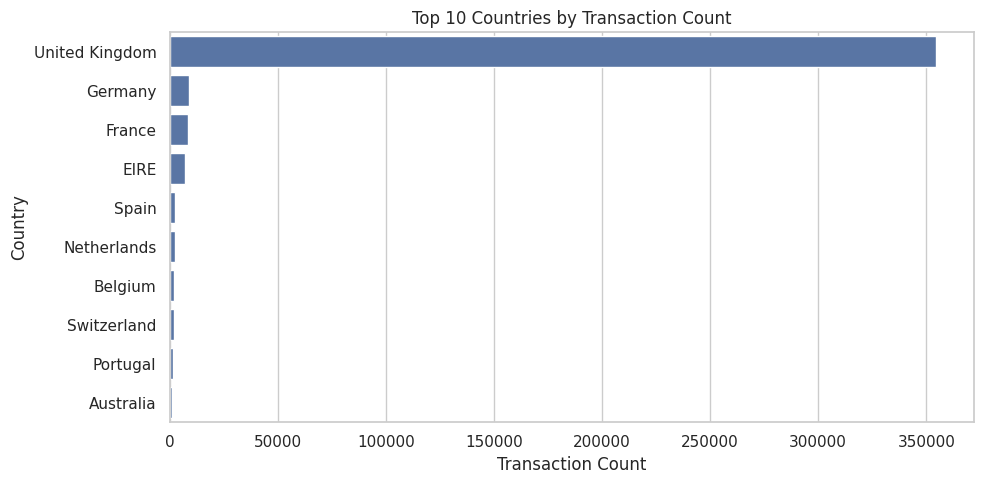

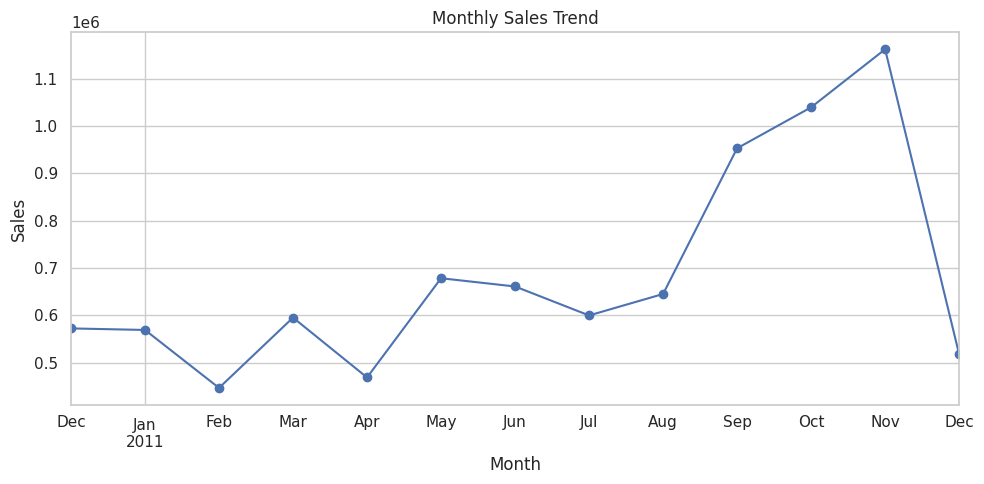

In [10]:
# Top countries by transaction count.
plt.figure(figsize=(10, 5))
top_countries = df_clean['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Transaction Count')
plt.xlabel('Transaction Count')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('figures/top_countries.png', dpi=300, bbox_inches='tight')
plt.show()

# Monthly sales trend.
monthly_sales = df_clean.set_index('InvoiceDate').resample('M')['TotalPrice'].sum()
plt.figure(figsize=(10, 5))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('figures/monthly_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Association Rule Mining / Market Basket Analysis

This section answers the first discovery question: **Which products are frequently purchased together?**

The dataset is transformed into basket format where each row is an invoice and each column is a product. The Apriori algorithm is then used to discover frequent itemsets and association rules.

In [11]:
# Prepare data for market basket analysis.
df_mb = df_clean[['InvoiceNo', 'Description', 'Quantity']].dropna()

# To keep the basket matrix manageable, product descriptions are stripped.
df_mb['Description'] = df_mb['Description'].astype(str).str.strip()

basket = df_mb.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

print('Basket shape:', basket.shape)
display(basket.head())

Basket shape: (18532, 3866)


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Apriori frequent itemsets and association rules.
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
rules = rules.sort_values(by=['lift', 'confidence'], ascending=False)

print('Number of frequent itemsets:', len(frequent_itemsets))
print('Number of association rules:', len(rules))

top_rules_table = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).copy()
top_rules_table['antecedents'] = top_rules_table['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
top_rules_table['consequents'] = top_rules_table['consequents'].apply(lambda x: ', '.join(sorted(list(x))))

display(top_rules_table)

Number of frequent itemsets: 243
Number of association rules: 32


,antecedents,consequents,support,confidence,lift
30,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.021045,0.701439,24.027846
26,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.021045,0.720887,24.027846
28,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.021045,0.894495,23.989564
29,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.021045,0.564399,23.989564
11,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.024822,0.827338,22.188466
10,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.024822,0.665702,22.188466
27,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.021045,0.847826,20.066300
16,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.023527,0.784173,18.559754
15,ROSES REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.023527,0.556833,18.559754
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.029193,0.782923,18.530185


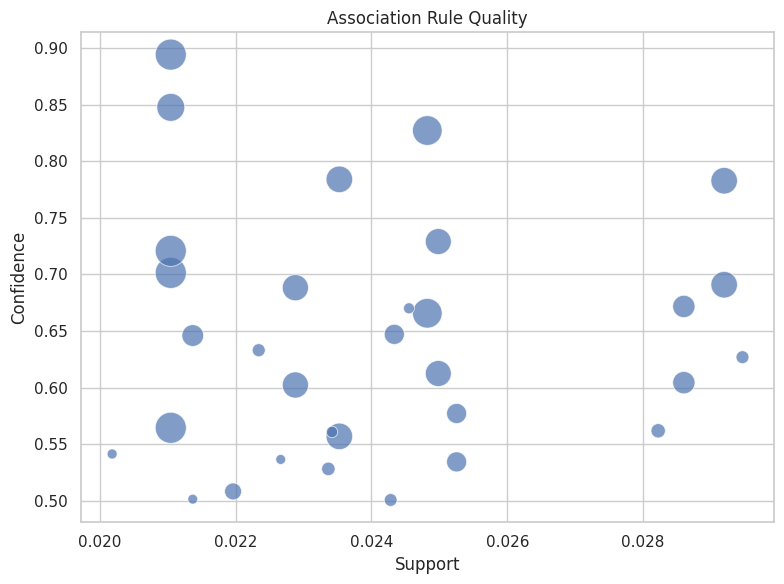

In [13]:
# Rule quality scatter plot.
if len(rules) > 0:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=rules,
        x='support',
        y='confidence',
        size='lift',
        sizes=(50, 500),
        alpha=0.7,
        legend=False
    )
    plt.title('Association Rule Quality')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.tight_layout()
    plt.savefig('figures/association_rule_quality.png', dpi=300, bbox_inches='tight')
    plt.show()

### Association Rule Interpretation

The association rule analysis identifies products that are frequently purchased together. In this project, many of the strongest rules involved tea cup and gift-related products. High lift values suggest that these relationships are stronger than random co-occurrence.

Business meaning:

- supports product bundling
- supports cross-selling
- supports recommendation systems

## 8. RFM Feature Engineering

This section creates customer-level RFM features:

- **Recency:** days since last purchase
- **Frequency:** number of unique invoices
- **Monetary:** total spending

These features are used for customer segmentation and anomaly detection.

In [14]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print('RFM shape:', rfm.shape)
display(rfm.head())
display(rfm[['Recency', 'Frequency', 'Monetary']].describe())

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


## 9. K-Means Customer Segmentation

This section answers the second discovery question: **Are there natural customer segments based on purchasing behavior?**

K-Means clustering is applied to standardized RFM features. The number of clusters is set to 4 because it produced interpretable customer groups: VIP, loyal, regular, and inactive customers.

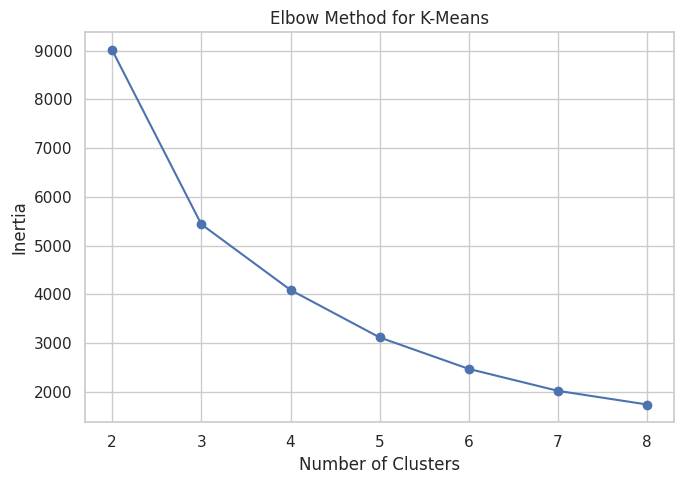

In [15]:
# Standardize RFM features.
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Elbow method for reference.
inertia = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(2, 9), inertia, marker='o')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('figures/elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# K-Means with 4 clusters.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print('Cluster counts:')
display(rfm['Cluster'].value_counts().sort_index())

cluster_summary = rfm.groupby('Cluster')[['CustomerID', 'Recency', 'Frequency', 'Monetary']].mean()
display(cluster_summary)

Cluster counts:


,count
Cluster,
0,3054
1,1067
2,13
3,204


,CustomerID,Recency,Frequency,Monetary
Cluster,,,,
0,15289.128356,43.702685,3.682711,1359.049284
1,15347.791940,248.075914,1.552015,480.617480
2,15435.000000,7.384615,82.538462,127338.313846
3,15212.857843,15.500000,22.333333,12709.090490


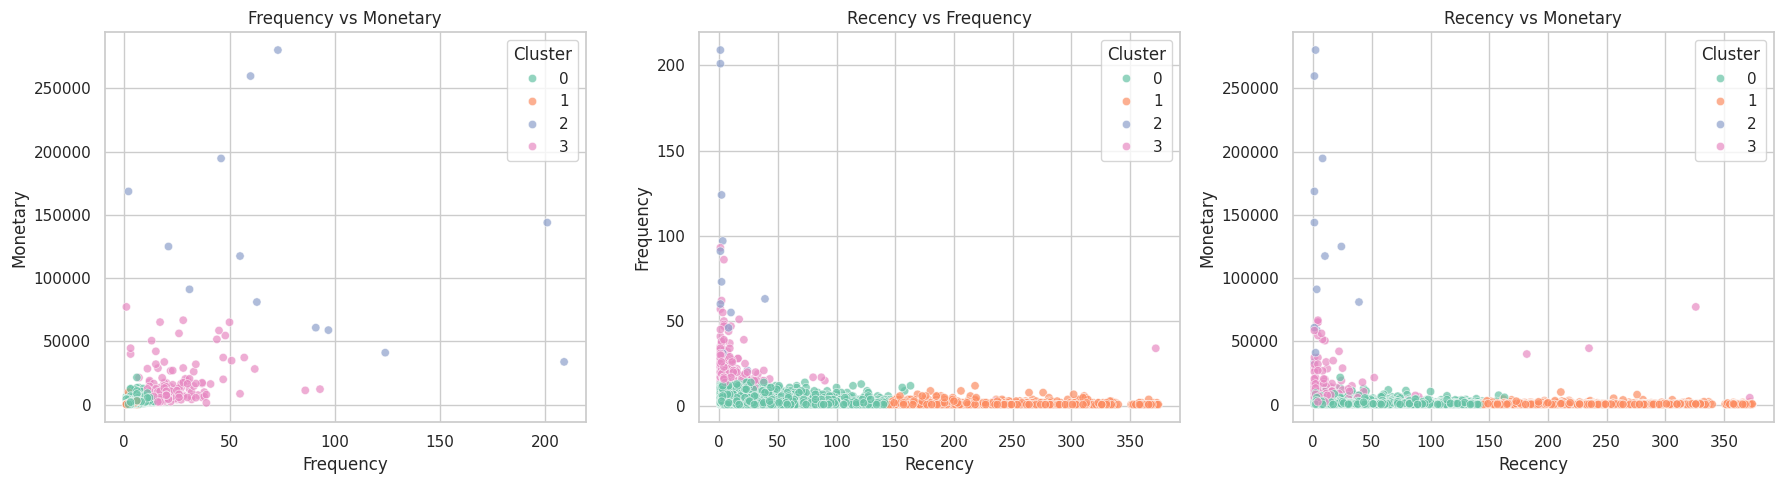

In [17]:
# RFM scatter plots.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[0], alpha=0.7)
axes[0].set_title('Frequency vs Monetary')

sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette='Set2', ax=axes[1], alpha=0.7)
axes[1].set_title('Recency vs Frequency')

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[2], alpha=0.7)
axes[2].set_title('Recency vs Monetary')

plt.tight_layout()
plt.savefig('figures/rfm_cluster_scatterplots.png', dpi=300, bbox_inches='tight')
plt.show()

### Customer Segmentation Interpretation

The clustering results identify four customer groups:

- **Cluster 2:** VIP or elite customers with very recent purchases, high frequency, and very high spending.
- **Cluster 3:** loyal high-value customers.
- **Cluster 0:** regular customers with moderate purchasing behavior.
- **Cluster 1:** inactive or low-value customers with long inactivity periods.

Cluster 2 is the highest-value group. These customers may represent VIP customers, wholesale buyers, or corporate accounts.

## 10. PCA Visualization

PCA is used to visualize customer structure in two dimensions and compare clustering on original RFM features with PCA-based clustering.

Explained variance ratio: [0.55502102 0.30249315]
Total explained variance: 0.8575141741259507


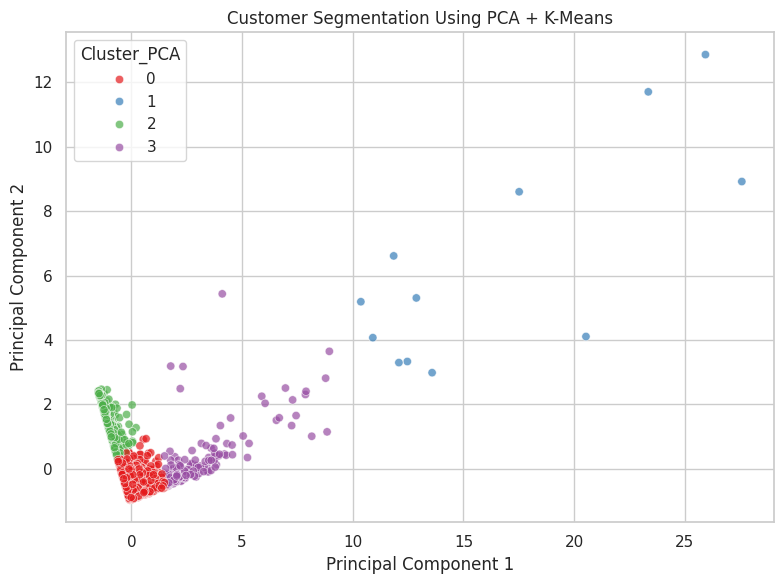

In [18]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance:', pca.explained_variance_ratio_.sum())

kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster_PCA'] = kmeans_pca.fit_predict(rfm_pca)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=rfm_pca[:, 0], y=rfm_pca[:, 1], hue=rfm['Cluster_PCA'], palette='Set1', alpha=0.7)
plt.title('Customer Segmentation Using PCA + K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig('figures/pca_kmeans_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

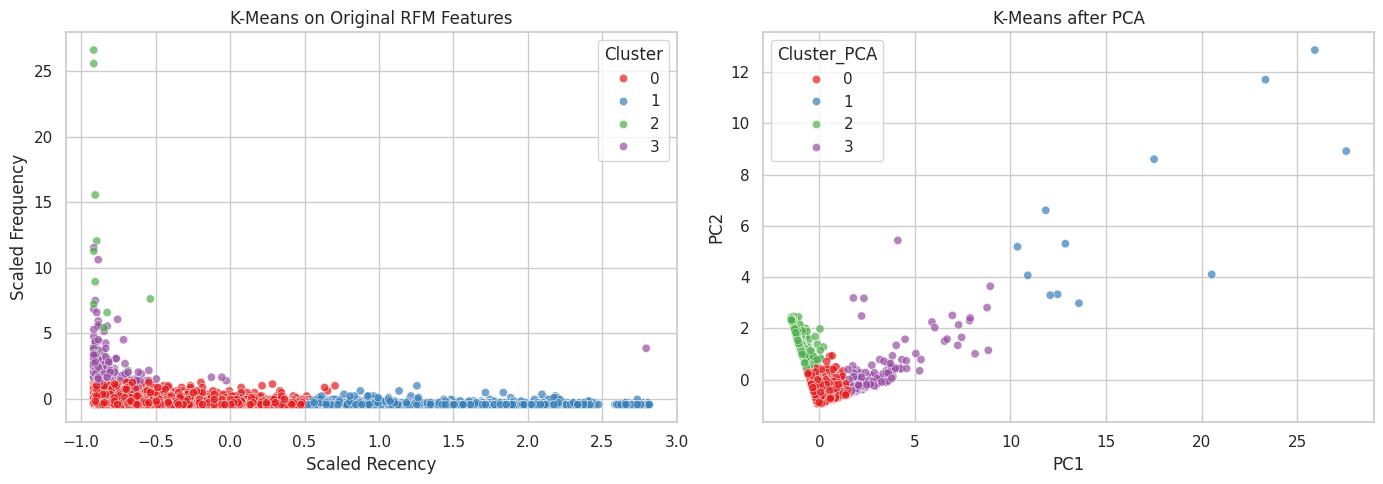

In [19]:
# Compare original feature space and PCA space.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=rfm_scaled[:, 0], y=rfm_scaled[:, 1], hue=rfm['Cluster'], palette='Set1', ax=axes[0], alpha=0.7)
axes[0].set_title('K-Means on Original RFM Features')
axes[0].set_xlabel('Scaled Recency')
axes[0].set_ylabel('Scaled Frequency')

sns.scatterplot(x=rfm_pca[:, 0], y=rfm_pca[:, 1], hue=rfm['Cluster_PCA'], palette='Set1', ax=axes[1], alpha=0.7)
axes[1].set_title('K-Means after PCA')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('figures/original_vs_pca_kmeans.png', dpi=300, bbox_inches='tight')
plt.show()

### PCA Interpretation

PCA makes the customer groups easier to visualize. Compared with the original RFM feature space, the PCA plot provides a clearer overall view of the customer structure. Some overlap still exists, but the clusters become easier to interpret visually.

## 11. Decision Tree Interpretation

A decision tree is used to explain the K-Means clusters. The goal is not mainly prediction, but interpretation. The tree helps identify which RFM features separate customer groups.

In [25]:
#Step 1: Prepare Features and Target
from sklearn.model_selection import train_test_split

X = rfm[['Recency', 'Frequency', 'Monetary']]

# Target: K-Means cluster labels
y = rfm['Cluster']

# Split into training and test sets for interpretability (not for strict prediction)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
#Step 2: Train a Shallow Decision Trees
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# Shallow tree for interpretability
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Evaluate (optional, just for info)
accuracy = dt.score(X_test, y_test)
print(f"Decision Tree Accuracy: {accuracy:.2f}")

Decision Tree Accuracy: 0.99


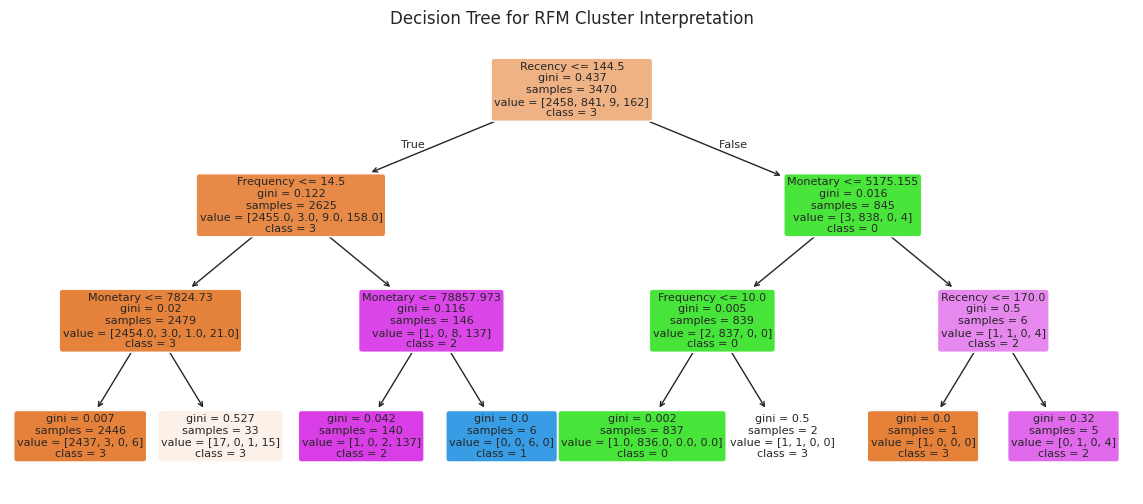

In [27]:
#Step 3: Visualize the Tree
plt.figure(figsize=(14.5,6))
tree.plot_tree(
    dt,
    feature_names=['Recency', 'Frequency', 'Monetary'],
    class_names=[str(c) for c in rfm['Cluster'].unique()],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree for RFM Cluster Interpretation")
plt.show()

In [24]:
def get_rules(model, feature_names):
    tree_ = model.tree_
    feature_name = [feature_names[i] if i != _tree.TREE_UNDEFINED else 'undefined' for i in tree_.feature]
    paths = []

    def recurse(node, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            recurse(tree_.children_left[node], path + [f'{name} <= {threshold:.2f}'])
            recurse(tree_.children_right[node], path + [f'{name} > {threshold:.2f}'])
        else:
            values = tree_.value[node][0]
            distribution = values / values.sum()
            paths.append((path, distribution))

    recurse(0, [])
    return paths

rules_dt = get_rules(dt, ['Recency', 'Frequency', 'Monetary'])

for i, (path, distribution) in enumerate(rules_dt, start=1):
    print(f'Rule {i}: IF ' + ' AND '.join(path))
    print('Cluster distribution:', np.round(distribution, 3))
    print()

Rule 1: IF Recency <= 144.50 AND Frequency <= 14.50 AND Monetary <= 8703.32
Cluster distribution: [0.995 0.002 0.    0.003]

Rule 2: IF Recency <= 144.50 AND Frequency <= 14.50 AND Monetary > 8703.32
Cluster distribution: [0.556 0.    0.037 0.407]

Rule 3: IF Recency <= 144.50 AND Frequency > 14.50 AND Frequency <= 58.50
Cluster distribution: [0.    0.    0.014 0.986]

Rule 4: IF Recency <= 144.50 AND Frequency > 14.50 AND Frequency > 58.50
Cluster distribution: [0.    0.    0.778 0.222]

Rule 5: IF Recency > 144.50 AND Monetary <= 24890.38 AND Frequency <= 8.50
Cluster distribution: [0.002 0.998 0.    0.   ]

Rule 6: IF Recency > 144.50 AND Monetary <= 24890.38 AND Frequency > 8.50
Cluster distribution: [0.5 0.5 0.  0. ]

Rule 7: IF Recency > 144.50 AND Monetary > 24890.38
Cluster distribution: [0. 0. 0. 1.]



### Decision Tree Interpretation

The decision tree shows that **Frequency** and **Monetary** are important for identifying high-value customers, while **Recency** is important for identifying inactive customers.

Two rules are especially useful:

- Customers with recent purchases, low frequency, and high spending may represent occasional wholesale buyers or company accounts.
- Customers with high historical spending but long inactivity periods may be dormant high-value customers who could be targeted with reactivation campaigns.

## 12. Naive Bayes Probabilistic Analysis

Naive Bayes is used here as a **discovery and interpretation tool**, not mainly as a prediction model. It helps examine conditional probability relationships between RFM feature ranges and customer clusters.

This section also directly addresses the M3 feedback: the full Naive Bayes report is included in the notebook output.

First 5 rows of discretized RFM features:


,Recency_bin,Frequency_bin,Monetary_bin
0,3,0,3
1,0,2,3
2,2,1,3
3,1,0,3
4,3,0,1


Naive Bayes agreement with K-Means cluster labels: 0.92

Full Classification Report / Probabilistic Consistency Summary:

              precision    recall  f1-score   support

           0       0.99      0.90      0.94       917
           1       0.98      0.99      0.99       320
           2       0.00      0.00      0.00         4
           3       0.36      0.82      0.50        61

    accuracy                           0.92      1302
   macro avg       0.58      0.68      0.61      1302
weighted avg       0.95      0.92      0.93      1302

Confusion Matrix:

[[827   5   0  85]
 [  0 318   0   2]
 [  2   0   0   2]
 [ 10   1   0  50]]

Class priors P(Cluster):
Cluster 0: 0.7039
Cluster 1: 0.2460
Cluster 2: 0.0030
Cluster 3: 0.0471


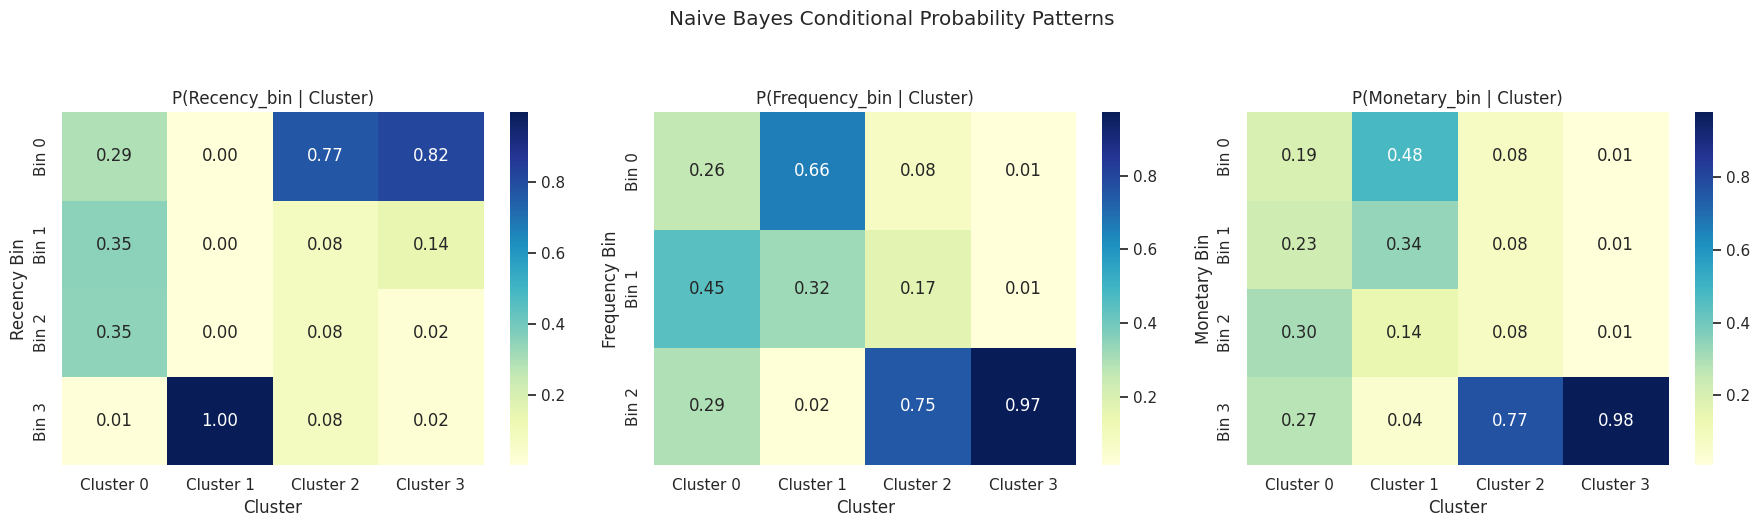

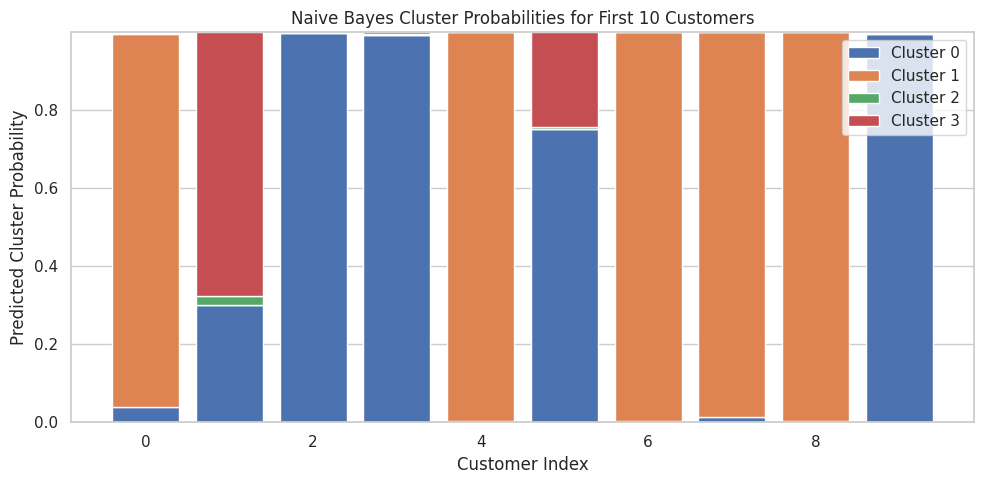


Explained variance ratio:
[0.55502102 0.30249315]
Total explained variance: 0.8575141741259507


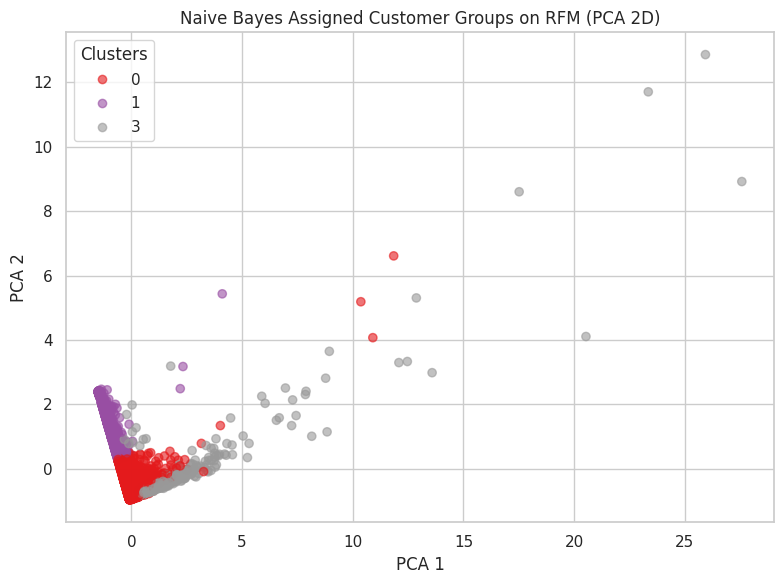

In [36]:
# Naive Bayes Probabilistic Analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

os.makedirs("figures", exist_ok=True)

# 1. Prepare features and target
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()
y = rfm['Cluster']

# 2. Discretize continuous RFM features for Categorical Naive Bayes
kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
X_binned = kbd.fit_transform(X).astype(int)

X_binned_df = pd.DataFrame(
    X_binned,
    columns=['Recency_bin', 'Frequency_bin', 'Monetary_bin']
)

print("First 5 rows of discretized RFM features:")
display(X_binned_df.head())

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_binned,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 4. Train Categorical Naive Bayes
nb = CategoricalNB()
nb.fit(X_train, y_train)

# 5. Probabilistic agreement with K-Means cluster labels
y_pred = nb.predict(X_test)
agreement = nb.score(X_test, y_test)

print(f"Naive Bayes agreement with K-Means cluster labels: {agreement:.2f}")

print("\nFull Classification Report / Probabilistic Consistency Summary:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# 6. Class priors
print("\nClass priors P(Cluster):")
class_priors = np.exp(nb.class_log_prior_)

for c, p in zip(nb.classes_, class_priors):
    print(f"Cluster {c}: {p:.4f}")

# 7. Conditional probability heatmaps combined into one figure
feature_names = ['Recency', 'Frequency', 'Monetary']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(feature_names):
    cond_prob_df = pd.DataFrame(
        np.exp(nb.feature_log_prob_[i]).T,
        columns=[f"Cluster {c}" for c in nb.classes_]
    )
    cond_prob_df.index = [f"Bin {j}" for j in range(cond_prob_df.shape[0])]

    sns.heatmap(
        cond_prob_df,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        ax=axes[i]
    )
    axes[i].set_title(f"P({feature}_bin | Cluster)")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(f"{feature} Bin")

plt.suptitle("Naive Bayes Conditional Probability Patterns", y=1.05)
plt.tight_layout()
plt.savefig("figures/naive_bayes_conditional_probabilities.png", dpi=300, bbox_inches="tight")
plt.show()

# 8. Optional: predicted cluster probabilities for first 10 customers
# This is useful for notebook exploration, but not necessary for the final report.
y_prob_all = nb.predict_proba(X_binned)

top_n = 10
y_prob_top = y_prob_all[:top_n]

plt.figure(figsize=(10, 5))
bottom = np.zeros(top_n)

for idx, cluster in enumerate(nb.classes_):
    plt.bar(
        range(top_n),
        y_prob_top[:, idx],
        bottom=bottom,
        label=f"Cluster {cluster}"
    )
    bottom += y_prob_top[:, idx]

plt.xlabel("Customer Index")
plt.ylabel("Predicted Cluster Probability")
plt.title("Naive Bayes Cluster Probabilities for First 10 Customers")
plt.legend()
plt.tight_layout()
plt.savefig("figures/naive_bayes_cluster_probabilities_top10.png", dpi=300, bbox_inches="tight")
plt.show()

# 9. PCA visualization of Naive Bayes assigned clusters
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

y_pred_all = nb.predict(X_binned)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_pred_all,
    cmap='Set1',
    alpha=0.6
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Naive Bayes Assigned Customer Groups on RFM (PCA 2D)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.tight_layout()
plt.savefig("figures/naive_bayes_predicted_clusters_pca.png", dpi=300, bbox_inches="tight")
plt.show()

### Naive Bayes Interpretation

The Naive Bayes analysis demonstrates probabilistic consistency between the RFM features and the overall customer cluster structure. VIP customers are strongly associated with high Frequency and high Monetary values, while inactive customers are more strongly associated with high Recency values, indicating longer inactivity periods.

The analysis also shows that the VIP customer group is relatively rare compared with the overall customer population. As a result, the probabilistic consistency for the VIP cluster is weaker than for larger customer groups. This class imbalance should be considered when interpreting the Naive Bayes results.

## 13. Anomaly Detection

This section answers the third discovery question: **Are there anomalous customers or unusual purchasing behaviors?**

Isolation Forest and LOF are used to identify statistically unusual customers. The results are compared to understand whether anomalies overlap with VIP customers.

In [31]:
anomaly_features = rfm[['Recency', 'Frequency', 'Monetary']]
anomaly_scaled = StandardScaler().fit_transform(anomaly_features)

iso_forest = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
rfm['IsolationForest_Anomaly'] = iso_forest.fit_predict(anomaly_scaled)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
rfm['LOF_Anomaly'] = lof.fit_predict(anomaly_scaled)

rfm['Combined_Anomaly'] = np.where(
    (rfm['IsolationForest_Anomaly'] == -1) | (rfm['LOF_Anomaly'] == -1),
    -1,
    1
)

print('Anomalies by Isolation Forest:', (rfm['IsolationForest_Anomaly'] == -1).sum())
print('Anomalies by LOF:', (rfm['LOF_Anomaly'] == -1).sum())
print('Combined anomalies:', (rfm['Combined_Anomaly'] == -1).sum())

Anomalies by Isolation Forest: 44
Anomalies by LOF: 44
Combined anomalies: 74


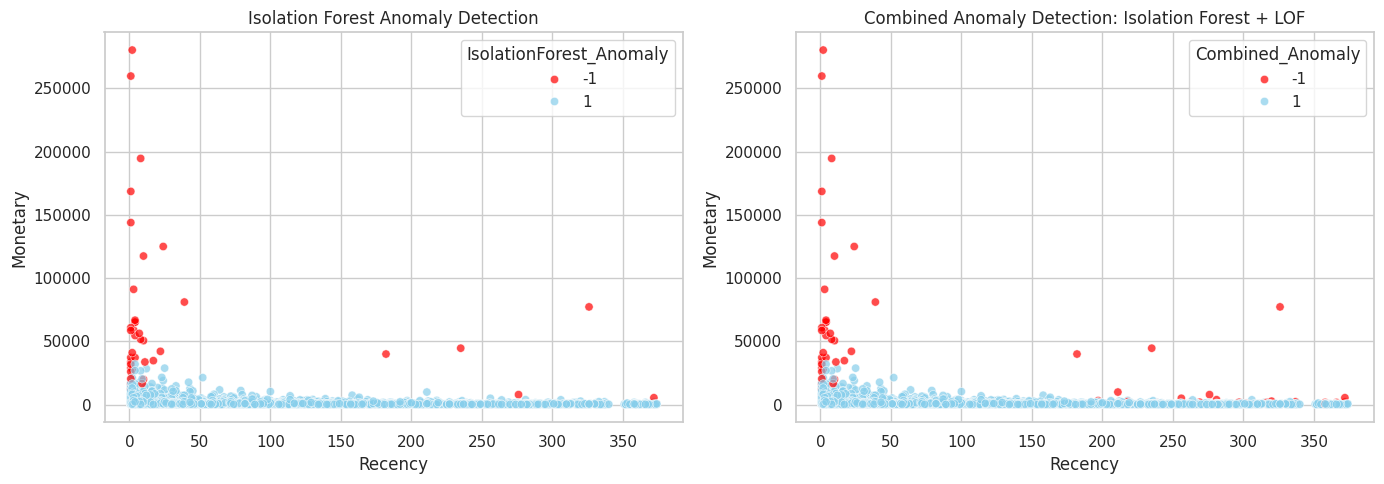

In [32]:
# Visualize Isolation Forest and combined anomaly detection.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='IsolationForest_Anomaly',
    palette={1: 'skyblue', -1: 'red'},
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Isolation Forest Anomaly Detection')
axes[0].set_xlabel('Recency')
axes[0].set_ylabel('Monetary')

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Combined_Anomaly',
    palette={1: 'skyblue', -1: 'red'},
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('Combined Anomaly Detection: Isolation Forest + LOF')
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')

plt.tight_layout()
plt.savefig('figures/anomaly_detection_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Top anomalous customers.
top_anomalies = rfm[rfm['Combined_Anomaly'] == -1].sort_values('Monetary', ascending=False)

display(top_anomalies[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'IsolationForest_Anomaly', 'LOF_Anomaly', 'Combined_Anomaly']].head(15))

## 14. VIP Customers vs. Anomalies

This section directly addresses the most important open question from M3 feedback: **Are Cluster 2 VIP customers and anomaly detection results the same population?**

The answer is: **partially overlapping, but not identical**.

In [33]:
# Relationship between clusters and anomalies.
overlap_table = pd.crosstab(rfm['Cluster'], rfm['Combined_Anomaly'])
overlap_table.columns = ['Anomaly' if c == -1 else 'Normal' for c in overlap_table.columns]
print('Cluster vs Combined Anomaly Count:')
display(overlap_table)

# Percentage version.
overlap_pct = pd.crosstab(rfm['Cluster'], rfm['Combined_Anomaly'], normalize='index') * 100
overlap_pct.columns = ['Anomaly_%' if c == -1 else 'Normal_%' for c in overlap_pct.columns]
print('Cluster vs Combined Anomaly Percentage:')
display(overlap_pct.round(2))

# Cluster summary including anomaly rates.
cluster_summary_final = rfm.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Anomaly_Rate=('Combined_Anomaly', lambda x: (x == -1).mean() * 100)
).round(2)

display(cluster_summary_final)

Cluster vs Combined Anomaly Count:


,Anomaly,Normal
Cluster,,
0,5,3049
1,26,1041
2,13,0
3,30,174


Cluster vs Combined Anomaly Percentage:


,Anomaly_%,Normal_%
Cluster,,
0,0.16,99.84
1,2.44,97.56
2,100.00,0.00
3,14.71,85.29


,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Anomaly_Rate
Cluster,,,,,
0,3054,43.70,3.68,1359.05,0.16
1,1067,248.08,1.55,480.62,2.44
2,13,7.38,82.54,127338.31,100.00
3,204,15.50,22.33,12709.09,14.71


### VIP vs. Anomaly Interpretation

Cluster 2 represents stable high-value customers based on RFM similarity. These customers usually have recent purchases, high purchase frequency, and high monetary value.

Anomaly detection identifies customers whose behavior is statistically unusual compared with the overall population. Therefore, many VIP customers can also be anomalies because their spending and frequency are far above normal customer behavior.

However, not all anomalies are Cluster 2 customers. Some anomalies may have unusual recency, irregular purchasing timing, or one-time bulk purchases. For example, CustomerID 14911 had a purchase frequency above 200, which suggests possible wholesale or company-account behavior.

Therefore, clustering and anomaly detection provide complementary insights:

- **Clustering** identifies stable customer behavior groups.
- **Anomaly detection** identifies statistically unusual behavior patterns.

## 15. K-Means Stability Check

M4 requires critical thinking about validity. To check whether K-Means results are reasonably stable, this section runs K-Means with different random seeds and compares cluster sizes.

In [34]:
seed_results = []
for seed in [0, 1, 7, 21, 42, 99]:
    km = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    counts = pd.Series(labels).value_counts().sort_index().to_dict()
    counts['seed'] = seed
    counts['inertia'] = km.inertia_
    seed_results.append(counts)

seed_df = pd.DataFrame(seed_results).fillna(0).set_index('seed')
display(seed_df)

,0,1,2,3,inertia
seed,,,,,
0,3054,1067,13,204,4092.145712
1,211,3052,13,1062,4092.209519
7,1062,211,3052,13,4092.209519
21,1063,3053,13,209,4092.173146
42,3054,1067,13,204,4092.144305
99,3052,1062,13,211,4092.209519


### Stability Interpretation

The K-Means stability check helps show whether the major cluster structure is consistent across different random seeds. Minor label changes can occur because cluster labels are arbitrary, but the main customer patterns remain interpretable: VIP/high-value customers, loyal customers, regular customers, and inactive customers.

## 16. Critical Assessment

### Validity

The findings are reasonably reliable because multiple methods identified similar customer behavior patterns. K-Means clustering, decision tree interpretation, Naive Bayes analysis, and anomaly detection all highlighted the importance of Frequency and Monetary values for high-value customers. PCA also improved the visualization of customer structure.

### Limitations

This project has several limitations:

- The dataset is mainly from a UK-based retailer, so results may not generalize to all markets.
- VIP customers are rare, which creates class imbalance.
- K-Means, Isolation Forest, and LOF are sensitive to parameter choices.
- Removing missing CustomerID records may introduce bias.
- The project focuses mainly on transaction data and does not include demographic or seasonal features.

### Ethical Considerations

Although the dataset is anonymized, customer behavior analysis still requires privacy awareness and responsible use. Businesses should avoid using segmentation results in ways that unfairly disadvantage customer groups. Bias should also be considered because the dataset mainly represents one retailer and one market.

## 17. Final Conclusion

This M4 notebook provides a complete and reproducible final version of the project.

The main findings are:

- Association rules identified meaningful product relationships that can support recommendation systems and cross-selling.
- K-Means clustering identified VIP, loyal, regular, and inactive customer groups.
- Decision trees provided interpretable business rules for cluster behavior.
- Naive Bayes provided probabilistic insight into how RFM features relate to customer groups.
- Isolation Forest and LOF identified unusual customers, including possible wholesalers and high-value outliers.
- VIP customers and anomalies are partially overlapping rather than identical populations.

Future work could include DBSCAN comparison, FP-Growth comparison, hierarchical clustering, time-series customer analysis, stronger validation, and improved anomaly tuning.